# Smartphone Price Prediction Analysis

## What is This Notebook?
**Goal**: Predict smartphone prices automatically using Artificial Intelligence (Machine Learning)

**How it works**:
- **Input**: Phone features (RAM, Battery, Camera, Processor, etc.)
- **Process**: Machine Learning algorithms learn patterns from data
- **Output**: Predicted phone price

## What We'll Do (Step by Step)

| Step | Task | What You'll See |
|------|------|----------------|
| 1️ | **Load Data** | Read 541 smartphones from Excel file |
| 2️ | **Clean Data** | Fix missing values, convert text to numbers |
| 3️ | **Visualize** | Beautiful charts to understand data patterns |
| 4️ | **Train Models** | Create 2 different AI models |
| 5️ | **Compare Models** | See which model is better |
| 6️ | **Feature Analysis** | Understand which phone features matter most |
| 7️ | **Final Results** | Summary with predictions and insights |

## Two AI Models We'll Use

**1. Linear Regression** - Simple & Fast
- Speed: Very fast
- Good for: Quick baseline predictions
- How it works: Draws a straight line through data

**2. Random Forest** - Complex & Accurate
- Speed: Slower but smarter
- Good for: More accurate predictions
- How it works: Uses many decision trees to make predictions

In [1]:
# ============================================
# STEP 0: Import All Required Tools (Libraries)
# ============================================
# Think of libraries as tools in a toolbox

import pandas as pd              # Tool for working with data (like Excel)
import numpy as np              # Tool for math calculations
import matplotlib.pyplot as plt  # Tool for creating graphs
import seaborn as sns           # Tool for beautiful statistical charts
from sklearn.model_selection import train_test_split  # Tool to split data into training & testing
from sklearn.linear_model import LinearRegression     # Tool for Linear model
from sklearn.ensemble import RandomForestRegressor    # Tool for Random Forest model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Tools to measure accuracy
import warnings
warnings.filterwarnings('ignore')  # Hide unnecessary warning messages

print("All tools loaded successfully!\n")

# Configure visualization settings
sns.set_style('whitegrid')           # Use grid background for charts
plt.rcParams['figure.figsize'] = (12, 6)  # Set default chart size

All tools loaded successfully!



## 1️ Load & Explore Data

**What we do**: Read the Excel file containing 541 smartphone records

**What to look for**:
- How many phones do we have?
- How many features/columns for each phone?
- What does the first few phones look like?

**Output**: Information about dataset size, first few rows, and column details

In [2]:
# Read data from Excel file into a table (called DataFrame)
df = pd.read_excel('Processed_Flipdata.xlsx')

# Display the size of data
print("\n" + "="*70)
print("DATASET SIZE")
print("="*70)
print(f"Total Phones: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print(f"Shape: {df.shape} (rows, columns)\n")
print("="*70)
print("First 5 Phones in Dataset")
print("="*70)
print(df.head())


DATASET SIZE
Total Phones: 541
Total Features: 12
Shape: (541, 12) (rows, columns)

First 5 Phones in Dataset
   Unnamed: 0            Model        Colour  Memory  RAM  Battery_  \
0           0  Infinix SMART 7   Night Black      64    4      6000   
1           1  Infinix SMART 7    Azure Blue      64    4      6000   
2           2     MOTOROLA G32  Mineral Gray     128    8      5000   
3           3         POCO C50    Royal Blue      32    2      5000   
4           4  Infinix HOT 30i      Marigold     128    8      5000   

  Rear Camera Front Camera  AI Lens  Mobile Height  \
0        13MP          5MP        1          16.76   
1        13MP          5MP        1          16.76   
2        50MP         16MP        0          16.64   
3         8MP          5MP        0          16.56   
4        50MP          5MP        1          16.76   

                   Processor_  Prize  
0  Unisoc Spreadtrum SC9863A1   7299  
1  Unisoc Spreadtrum SC9863A1   7299  
2     Qualcomm Snapd

In [3]:
# Get detailed information about data
print("\n" + "="*70)
print("DETAILED INFORMATION ABOUT EACH COLUMN")
print("="*70)
print(df.info())

# Get statistics (average, min, max, etc.)
print("\n" + "="*70)
print("STATISTICS (Average, Min, Max, etc.)")
print("="*70)

print(df.describe())
print("\n Tip: Look at the 'mean' (average) for each feature")



DETAILED INFORMATION ABOUT EACH COLUMN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 50.8+ KB
None

STATISTICS (Average, Min, Max, etc.)
       Unnamed: 0      Memory         RAM     Battery_     AI Lens  \
count  541.000000  541.000000  541.000000   541.000000  541.000

In [4]:
# Check for empty/missing values in data
print("\n" + "="*70)
print("CHECKING FOR MISSING/EMPTY VALUES")
print("="*70)
missing_values = df.isnull().sum()
missing_count = missing_values.sum()

if missing_count > 0:
    print(f"Found {missing_count} missing values:")
    print(missing_values[missing_values > 0])
    print("\n Fixing missing values...")
    # Fill missing values using forward fill
    df.fillna(method='ffill', inplace=True)
    # Fill remaining with backward fill
    df.fillna(method='bfill', inplace=True)
    print(f" Fixed! Remaining missing values: {df.isnull().sum().sum()}")
else:
    print(" Great! No missing values found.")


CHECKING FOR MISSING/EMPTY VALUES
 Great! No missing values found.


## 2️ Clean & Organize Data

**What we do**: Convert text data to numbers so the AI can understand it

**Why?** AI and Machine Learning models only understand numbers, not text!

**Example of text-to-number conversion**:
- "iPhone" → 1, "Samsung" → 2, "Motorola" → 3 (Brand names)
- "Red" → 1, "Blue" → 2, "Black" → 3 (Colors)

**Process**: We use "One-Hot Encoding" to create new columns with 1s and 0s

**Output**: All 613+ columns are now numbers, ready for AI models

In [5]:
# CONVERT TEXT DATA TO NUMBERS
print("\n" + "="*70)
print(" CONVERTING TEXT TO NUMBERS")
print("="*70)

# Find all text columns (called 'object' type)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Text columns found: {categorical_cols}")
print(f"Total text columns: {len(categorical_cols)}\n")

# Convert text to numbers using One-Hot Encoding
# This creates new columns with 1s and 0s
if len(categorical_cols) > 0:
    print("Converting text to numbers...")
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print(f" Conversion complete!\n")

# Ensure all columns are numeric
df = df.apply(pd.to_numeric, errors='coerce')
df = df.fillna(df.mean())

print(f"\nAll {df.shape[1]} columns are now NUMBERS ")
print("="*70)
print(f"Total features: {df.shape[1]}")
print(" FINAL DATA READY FOR AI")
print(f"Dataset shape: {df.shape}")
print("="*70)


 CONVERTING TEXT TO NUMBERS
Text columns found: ['Model', 'Colour', 'Rear Camera', 'Front Camera', 'Processor_']
Total text columns: 5

Converting text to numbers...
 Conversion complete!


All 614 columns are now NUMBERS 
Total features: 614
 FINAL DATA READY FOR AI
Dataset shape: (541, 614)



Outlier Detection - Boxplot Analysis:


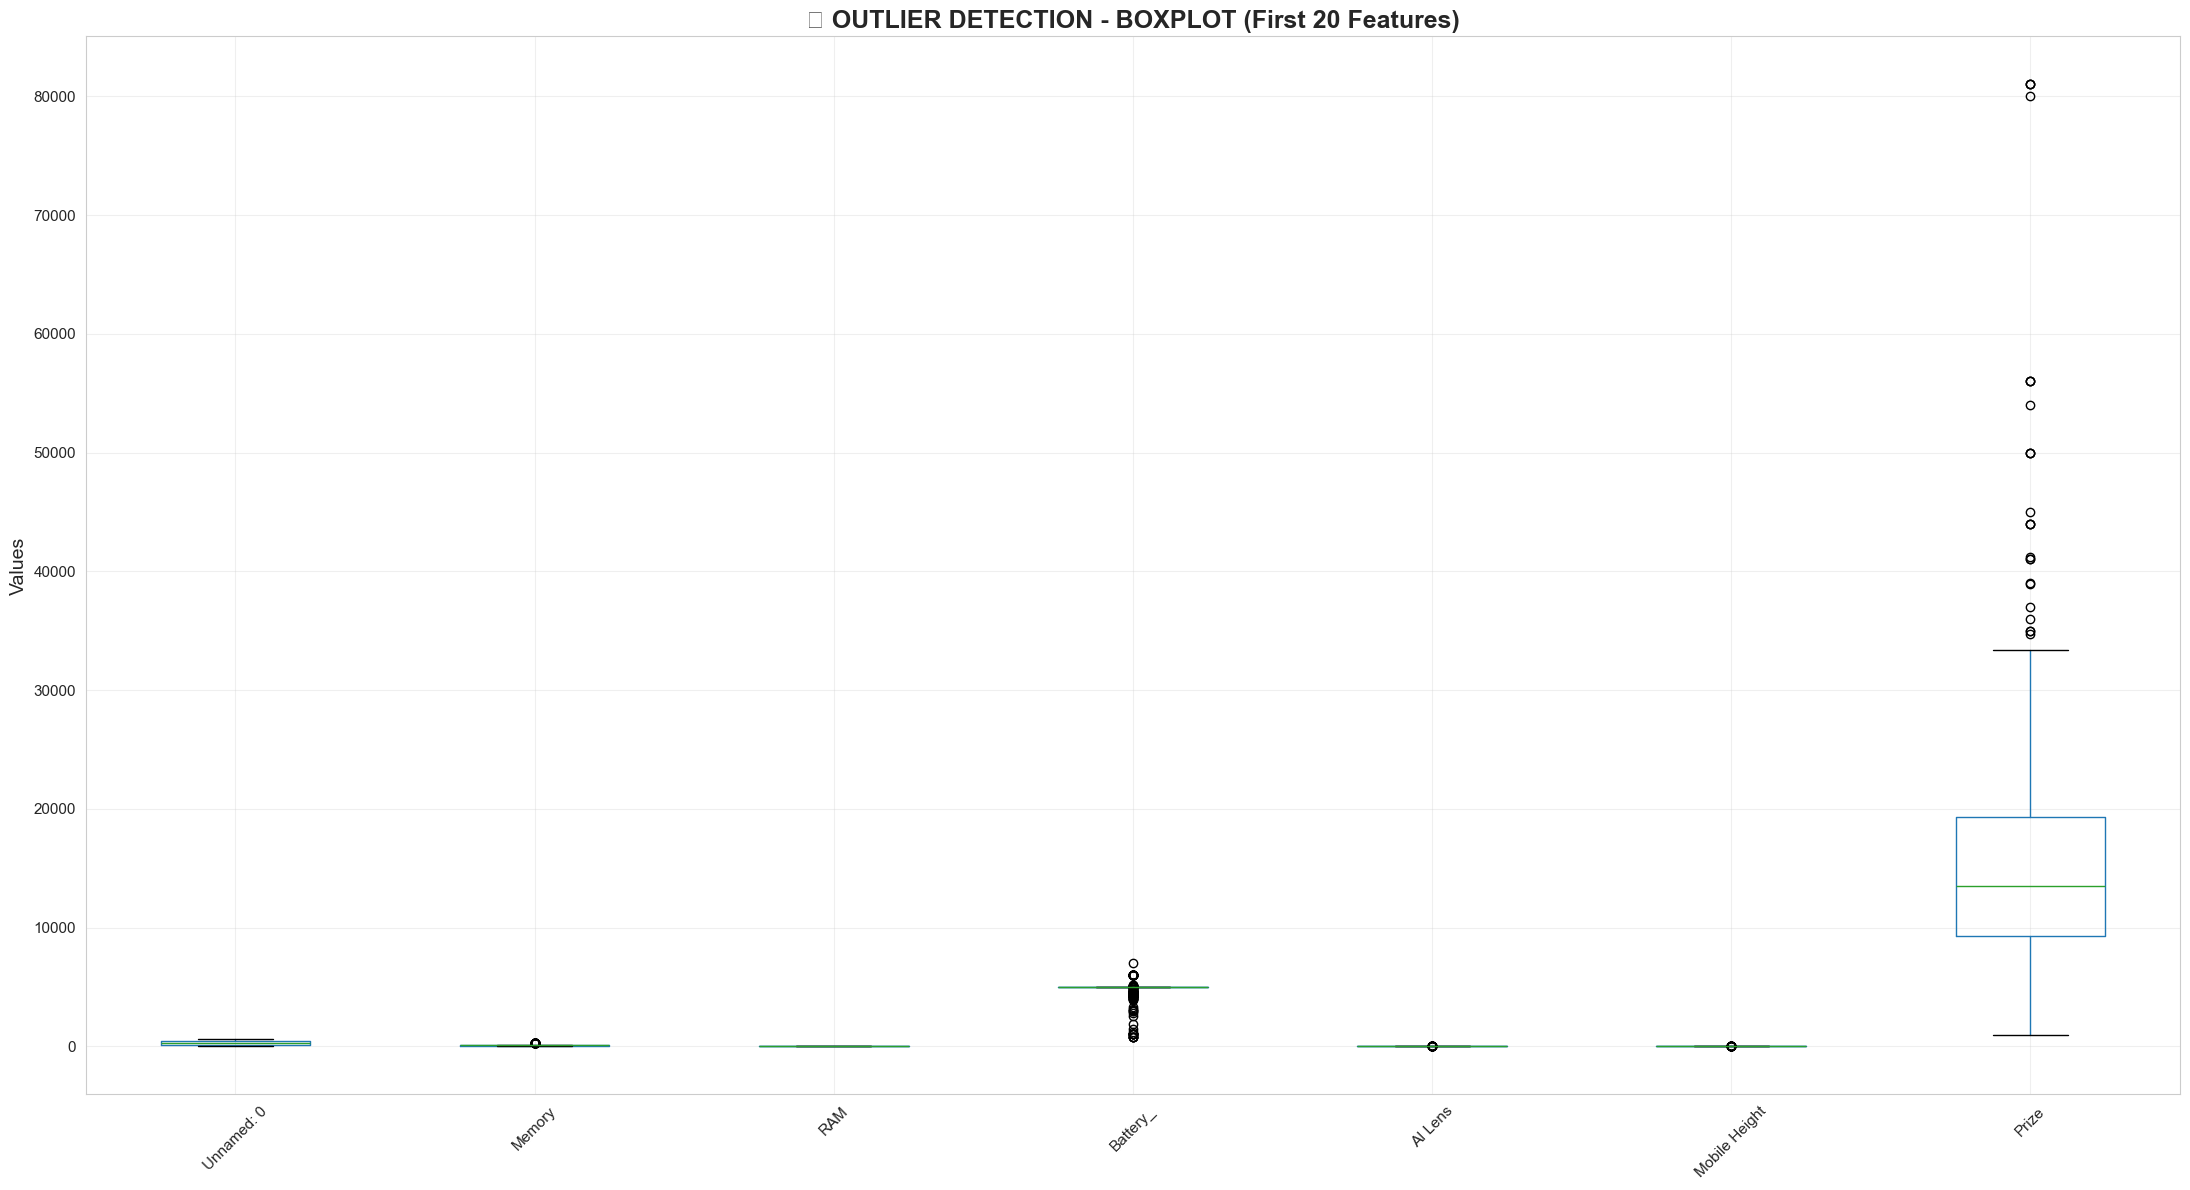

Boxplot created for 7 numeric features


In [6]:
# Exploratory Data Analysis - Visualize distributions
print("\n" + "="*50)
print("Outlier Detection - Boxplot Analysis:")
print("="*50)

# Select only numeric columns for boxplot
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 1:
    # Limit to reasonable number of columns for display
    display_cols = numeric_cols[:20] if len(numeric_cols) > 20 else numeric_cols
    plt.figure(figsize=(22, 12))
    df[display_cols].boxplot(fontsize=12)
    plt.title('📦 OUTLIER DETECTION - BOXPLOT (First 20 Features)', fontsize=18, fontweight='bold')
    plt.xticks(rotation=45, fontsize=11)
    plt.yticks(fontsize=11)
    plt.ylabel('Values', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
print(f"Boxplot created for {len(display_cols)} numeric features")

## 3️ Visualize Data with Graphs

**What we do**: Create beautiful charts to understand data patterns

**Why?** Graphs help us "see" patterns that numbers can't show easily

**Graphs we create**:
1. **Boxplot** - Finds unusual/extreme values (Outliers)
2. **Correlation Heatmap** - Shows which features are related to each other

**Output**: Large, beautiful graphs showing data relationships


Correlation Matrix:
Correlation matrix shape: (7, 7)


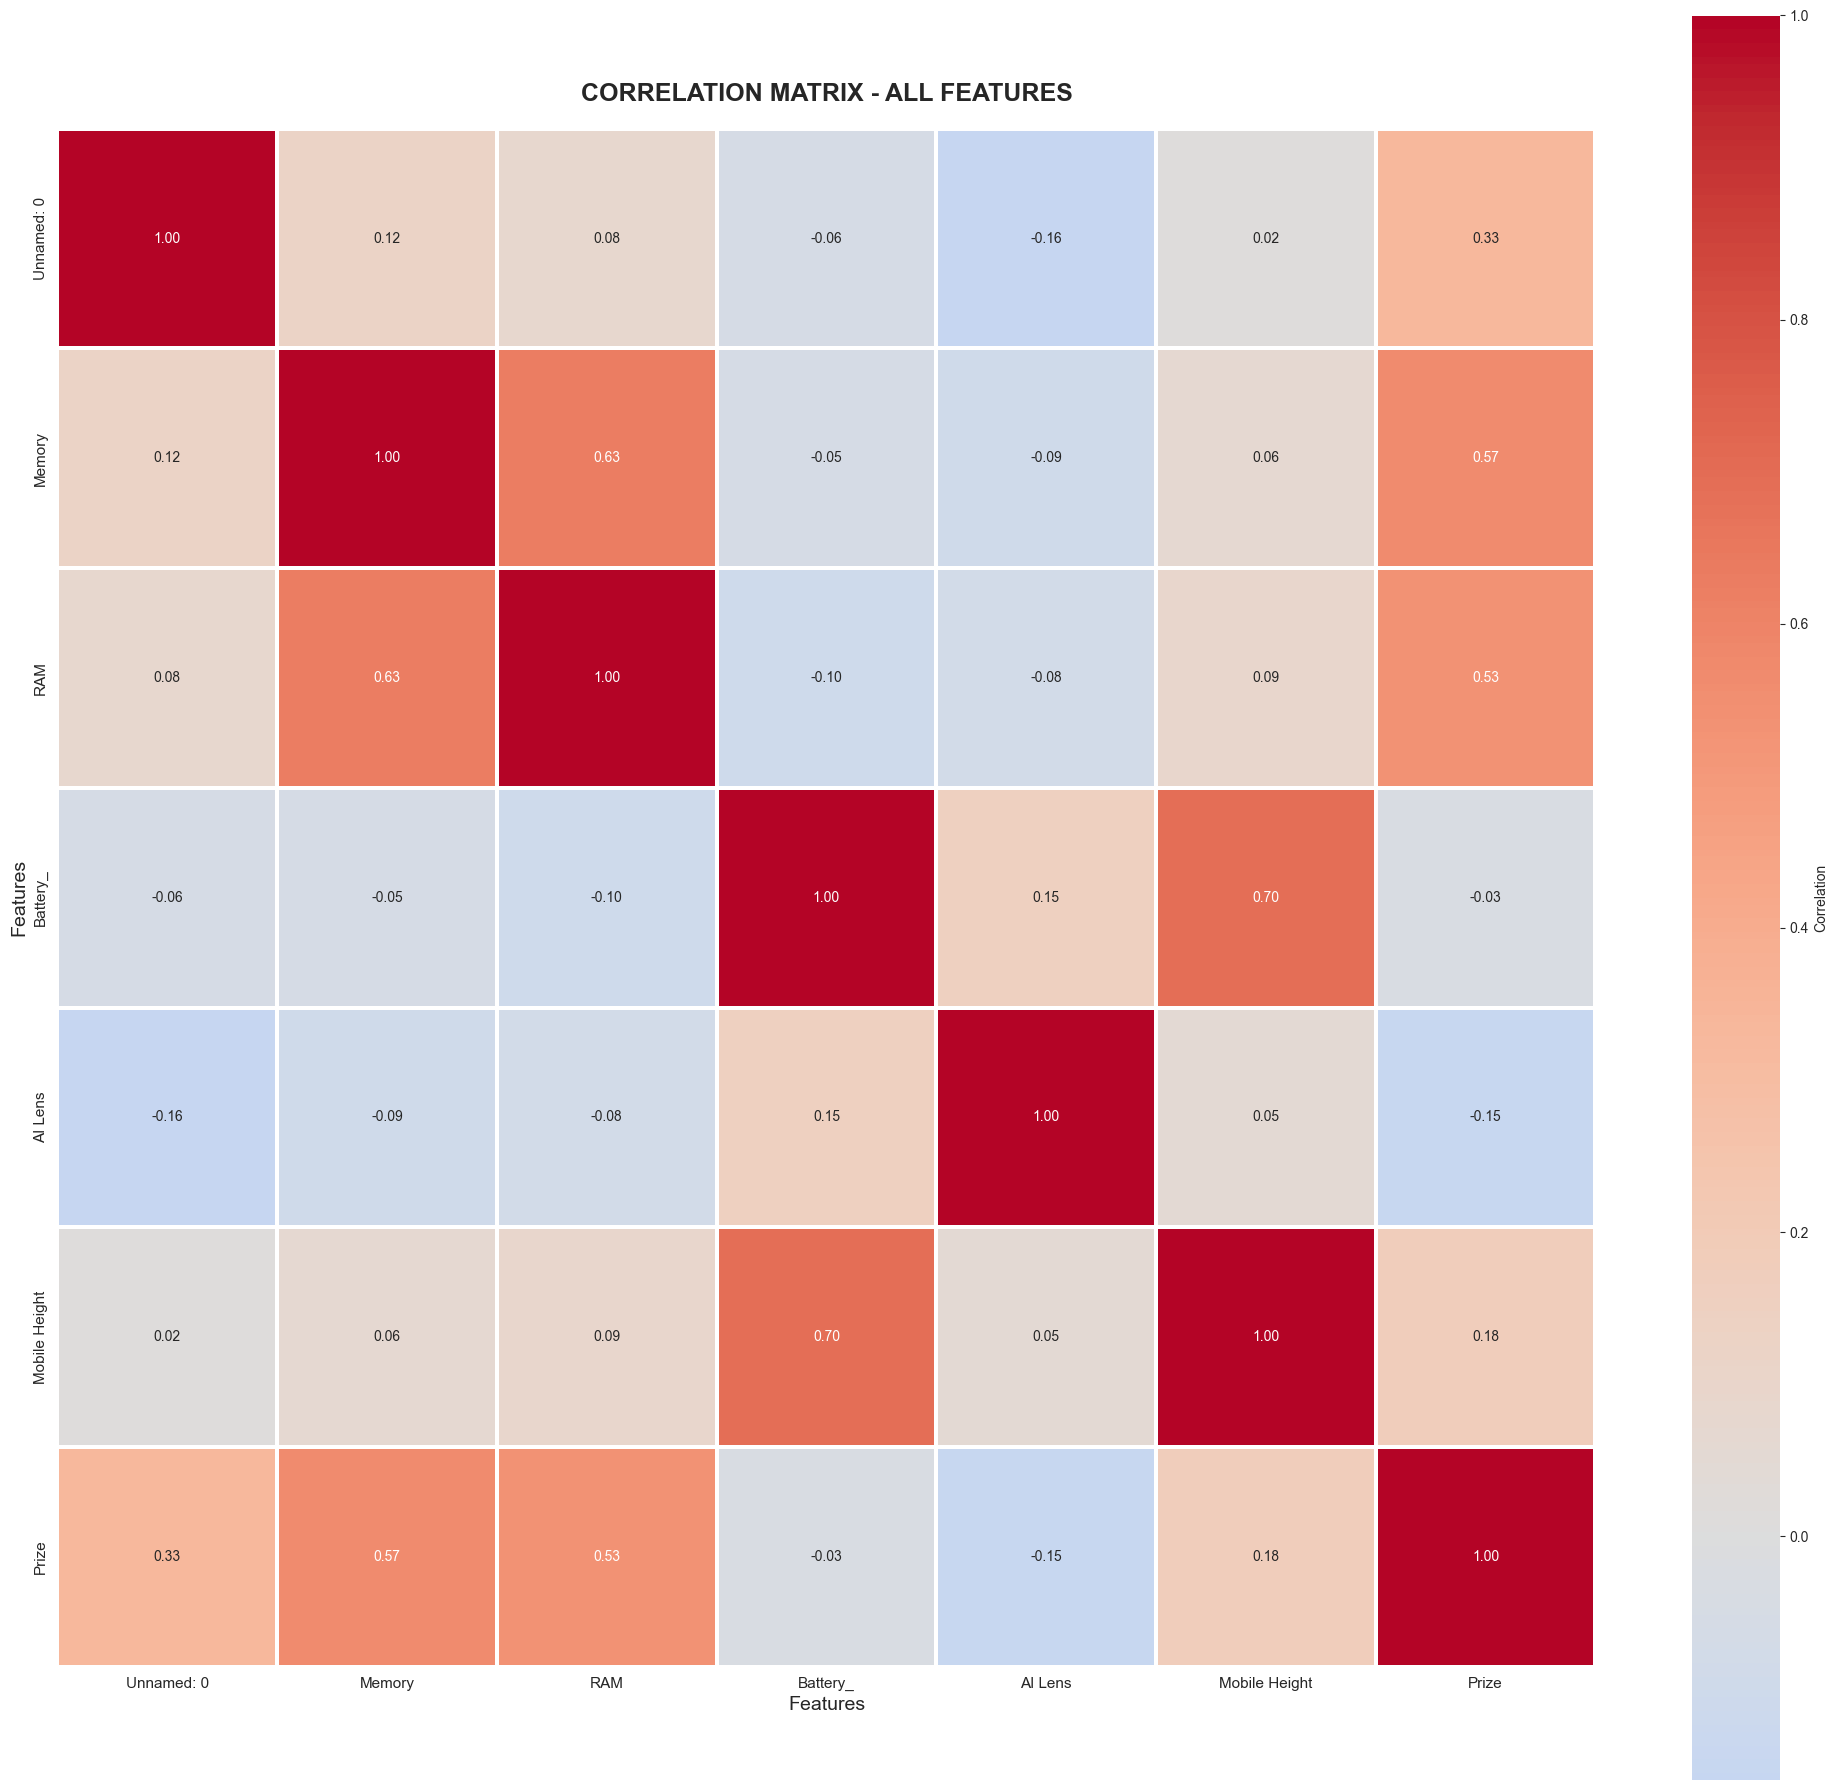

Correlation matrix visualization complete


In [7]:
# Correlation Analysis
print("\n" + "="*50)
print("Correlation Matrix:")
print("="*50)

# Calculate correlation matrix only for numeric columns
numeric_data = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr()

print(f"Correlation matrix shape: {correlation_matrix.shape}")

# Plot correlation heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1.5, cbar_kws={'label': 'Correlation'},
            annot_kws={'fontsize': 10})
plt.title('CORRELATION MATRIX - ALL FEATURES', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()
print("Correlation matrix visualization complete")

In [8]:
# Prepare data for modeling - Separate features and target
print("\n" + "="*50)
print("Model Preparation:")
print("="*50)

# Identify target variable (usually the last numeric column or 'Price')
# If 'Price' exists, use it; otherwise use the last column
if 'Price' in df.columns:
    target_col = 'Price'
elif 'Prize' in df.columns:
    target_col = 'Prize'
else:
    # Find the last numeric column
    numeric_data = df.select_dtypes(include=[np.number])
    target_col = numeric_data.columns[-1]

print(f"Target variable: {target_col}")

# Separate features (X) and target (y)
X = df.drop(target_col, axis=1)
y = df[target_col]

# Ensure both X and y have only numeric values
X = X.select_dtypes(include=[np.number])
y = pd.to_numeric(y, errors='coerce')
X = X.dropna()
y = y[X.index]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Data ready for modeling")


Model Preparation:
Target variable: Prize
Features shape: (541, 6)
Target shape: (541,)
Data ready for modeling


## 4️ Train AI Models

**What we do**: Teach the AI to predict phone prices using the phone data

**How it works**:
1. Split data into two groups: Training (80%) and Testing (20%)
2. Train both models on the training data
3. Test both models on new data they haven't seen before

**Models trained**:
- Linear Regression (simple model)
- Random Forest (advanced model with 100 trees)

**Output**: Accuracy scores (MAE, RMSE, R²) for both models

In [9]:
# Train-Test Split
print("\n" + "="*50)
print("Train-Test Split:")
print("="*50)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training percentage: {(X_train.shape[0] / len(X)) * 100:.2f}%")
print(f"Test percentage: {(X_test.shape[0] / len(X)) * 100:.2f}%")


Train-Test Split:
Training set size: 432 samples
Test set size: 109 samples
Training percentage: 79.85%
Test percentage: 20.15%


In [10]:
# Model 1: Linear Regression
print("\n" + "="*50)
print("Model 1: Linear Regression")
print("="*50)

# Train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_train_pred_lr = lr_model.predict(X_train)
y_test_pred_lr = lr_model.predict(X_test)

# Evaluate on training set
train_mae_lr = mean_absolute_error(y_train, y_train_pred_lr)
train_rmse_lr = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
train_r2_lr = r2_score(y_train, y_train_pred_lr)

# Evaluate on test set
test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)
test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
test_r2_lr = r2_score(y_test, y_test_pred_lr)

print(f"\nTraining Metrics:")
print(f"  MAE:  {train_mae_lr:.4f}")
print(f"  RMSE: {train_rmse_lr:.4f}")
print(f"  R²:   {train_r2_lr:.4f}")

print(f"\nTest Metrics:")
print(f"  MAE:  {test_mae_lr:.4f}")
print(f"  RMSE: {test_rmse_lr:.4f}")
print(f"  R²:   {test_r2_lr:.4f}")


Model 1: Linear Regression

Training Metrics:
  MAE:  4418.8531
  RMSE: 7546.2826
  R²:   0.4858

Test Metrics:
  MAE:  4667.4875
  RMSE: 9209.6260
  R²:   0.3846


In [11]:
# Model 2: Random Forest Regressor
print("\n" + "="*50)
print("Model 2: Random Forest Regressor")
print("="*50)

# Train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Evaluate on training set
train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
train_rmse_rf = np.sqrt(mean_squared_error(y_train, y_train_pred_rf))
train_r2_rf = r2_score(y_train, y_train_pred_rf)

# Evaluate on test set
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
test_rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print(f"\nTraining Metrics:")
print(f"  MAE:  {train_mae_rf:.4f}")
print(f"  RMSE: {train_rmse_rf:.4f}")
print(f"  R²:   {train_r2_rf:.4f}")

print(f"\nTest Metrics:")
print(f"  MAE:  {test_mae_rf:.4f}")
print(f"  RMSE: {test_rmse_rf:.4f}")
print(f"  R²:   {test_r2_rf:.4f}")


Model 2: Random Forest Regressor

Training Metrics:
  MAE:  915.7280
  RMSE: 1821.4317
  R²:   0.9700

Test Metrics:
  MAE:  2365.5303
  RMSE: 5378.1873
  R²:   0.7901


In [12]:
# Model Comparison
print("\n" + "="*50)
print("Model Comparison - Test Set Performance")
print("="*50)

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [test_mae_lr, test_mae_rf],
    'RMSE': [test_rmse_lr, test_rmse_rf],
    'R² Score': [test_r2_lr, test_r2_rf]
})

print(comparison_df.to_string(index=False))

# Determine best model
best_model = 'Random Forest' if test_r2_rf > test_r2_lr else 'Linear Regression'
print(f"\n✓ Best Model: {best_model}")


Model Comparison - Test Set Performance
            Model         MAE        RMSE  R² Score
Linear Regression 4667.487471 9209.626021  0.384615
    Random Forest 2365.530275 5378.187308  0.790137

✓ Best Model: Random Forest


## 5️-Compare Model Performance

**What we do**: Compare which model predicts phone prices better

**Metrics we use**:
- **MAE** (Mean Absolute Error): Average prediction error in rupees
- **RMSE** (Root Mean Squared Error): Different way to measure error
- **R² Score**: How well the model fits (1.0 = perfect, 0.0 = poor)

**Decision**: We pick the model with highest R² score

**Output**: Comparison table and winner announcement


Feature Importance (Random Forest)

Top 10 Important Features:
      Feature  Importance
       Memory    0.290455
     Battery_    0.226194
   Unnamed: 0    0.174488
Mobile Height    0.164171
          RAM    0.144071
      AI Lens    0.000622


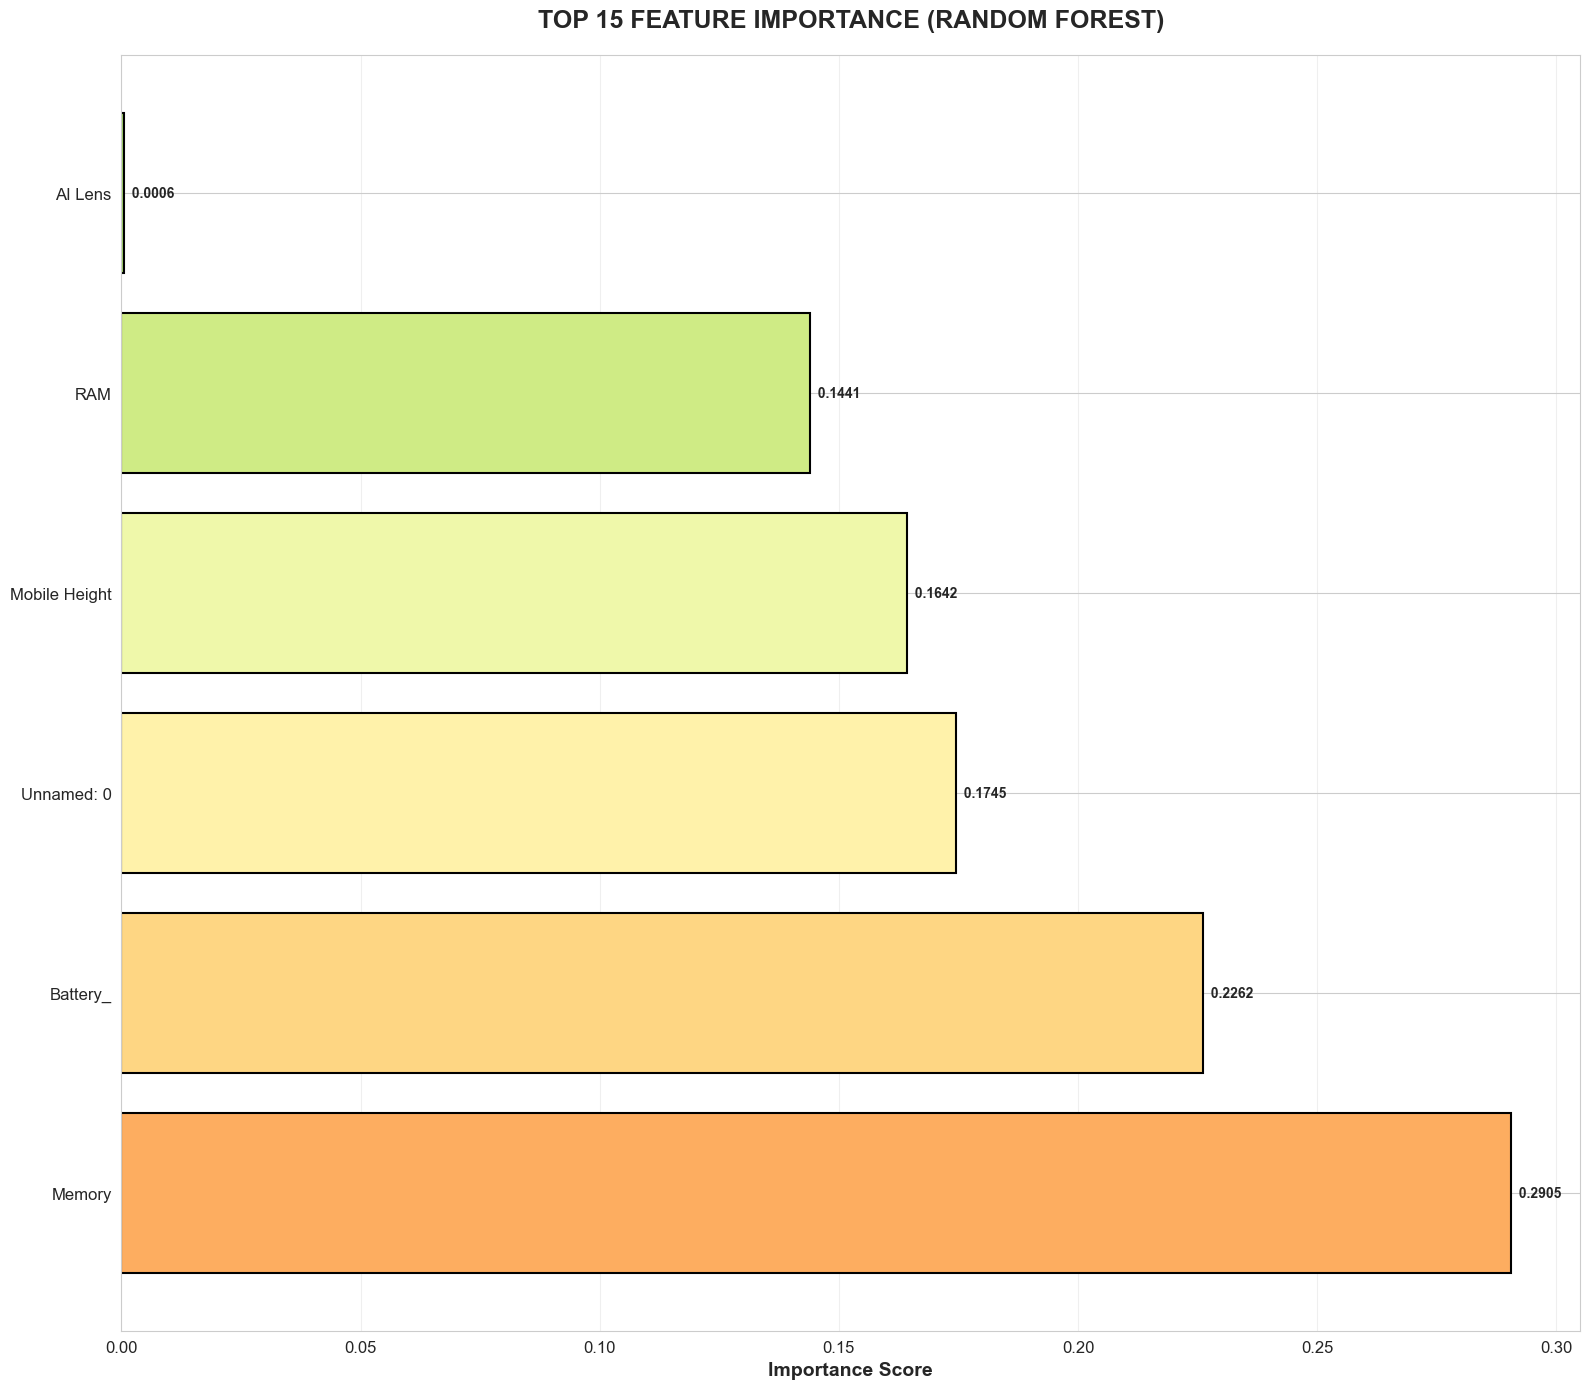

In [13]:
# Feature Importance Analysis
print("\n" + "="*50)
print("Feature Importance (Random Forest)")
print("="*50)

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(16, 14))
top_features = feature_importance.head(15)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.7, len(top_features)))
bars = plt.barh(range(len(top_features)), top_features['Importance'], color=colors, edgecolor='black', linewidth=1.5)
plt.yticks(range(len(top_features)), top_features['Feature'], fontsize=12)
plt.xlabel('Importance Score', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.title('TOP 15 FEATURE IMPORTANCE (RANDOM FOREST)', fontsize=18, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3, axis='x')
# Add value labels on bars
for i, (idx, row) in enumerate(top_features.iterrows()):
    plt.text(row['Importance'], i, f"  {row['Importance']:.4f}", va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


Prediction Analysis


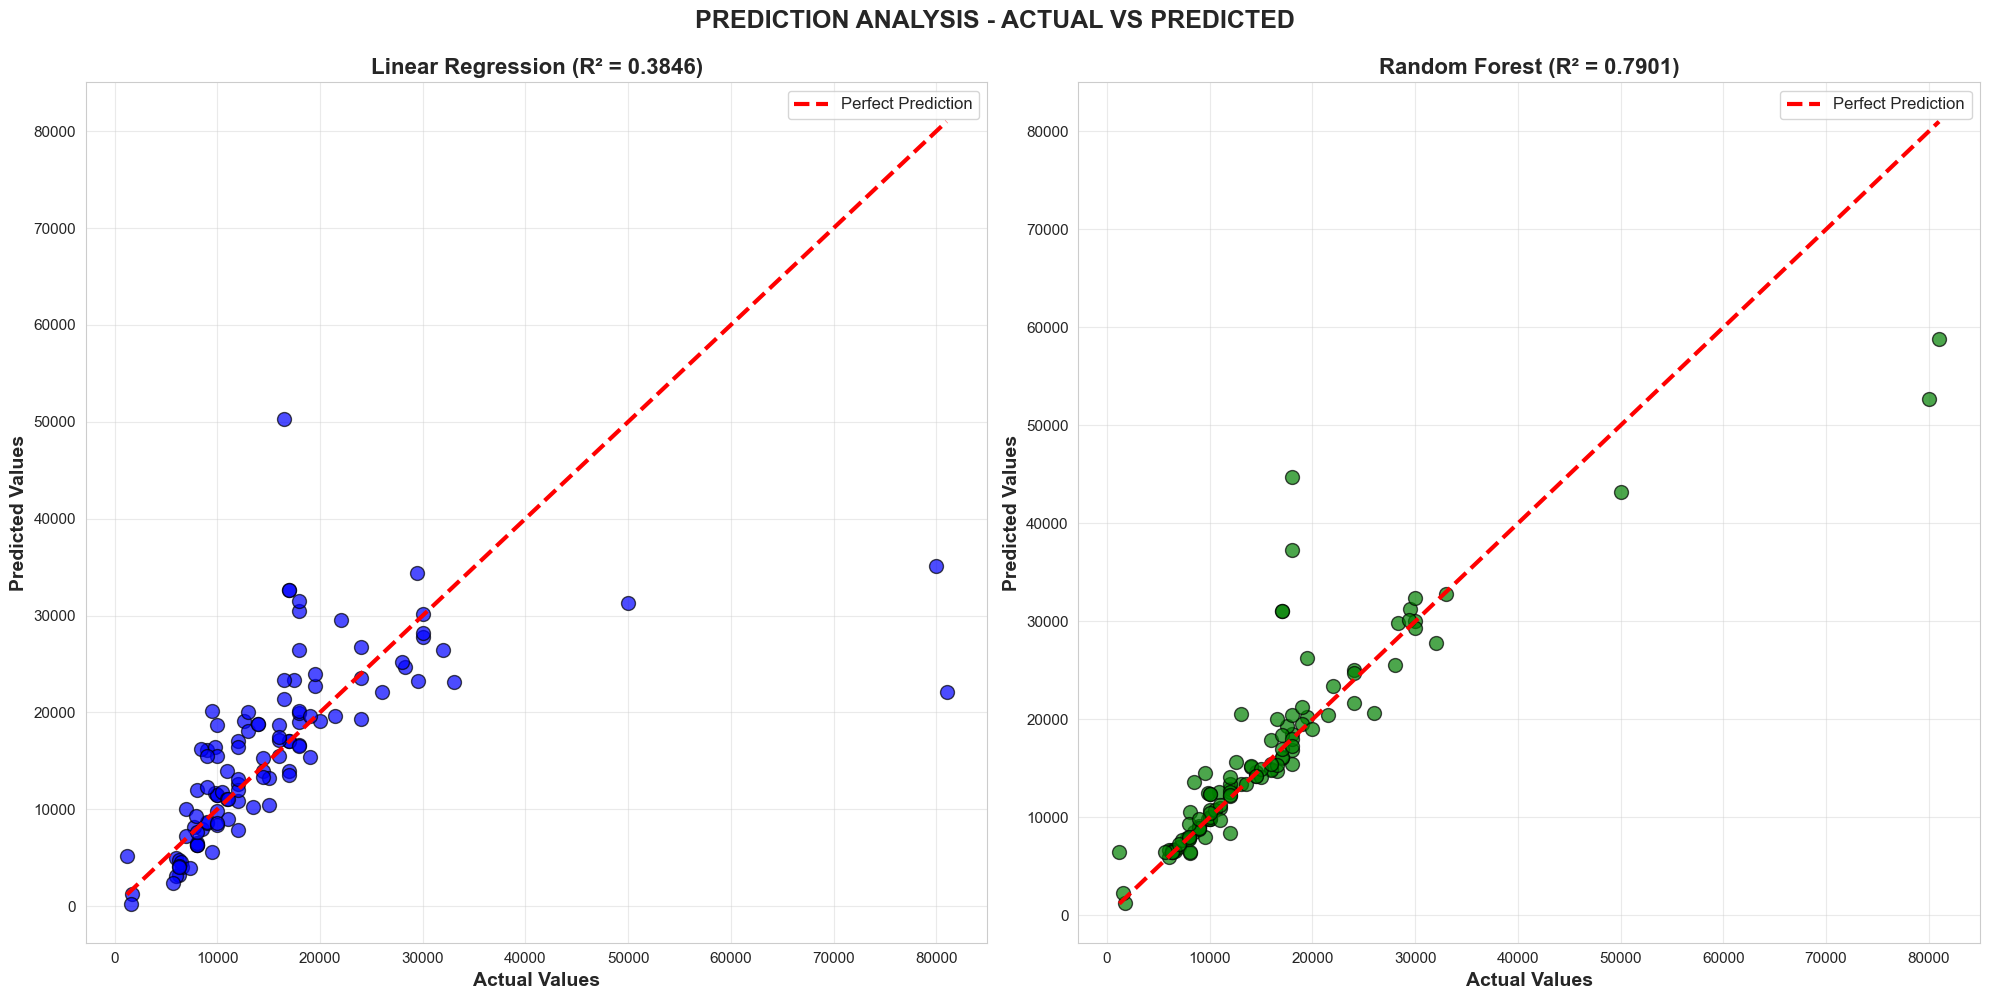

In [14]:
# Actual vs Predicted Visualization
print("\n" + "="*50)
print("Prediction Analysis")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Linear Regression
axes[0].scatter(y_test, y_test_pred_lr, alpha=0.7, color='blue', s=100, edgecolor='black', linewidth=1)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Predicted Values', fontsize=14, fontweight='bold')
axes[0].set_title(f'Linear Regression (R² = {test_r2_lr:.4f})', fontsize=16, fontweight='bold')
axes[0].grid(True, alpha=0.4)
axes[0].legend(fontsize=12)
axes[0].tick_params(labelsize=11)

# Random Forest
axes[1].scatter(y_test, y_test_pred_rf, alpha=0.7, color='green', s=100, edgecolor='black', linewidth=1)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3, label='Perfect Prediction')
axes[1].set_xlabel('Actual Values', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Predicted Values', fontsize=14, fontweight='bold')
axes[1].set_title(f'Random Forest (R² = {test_r2_rf:.4f})', fontsize=16, fontweight='bold')
axes[1].grid(True, alpha=0.4)
axes[1].legend(fontsize=12)
axes[1].tick_params(labelsize=11)
fig.suptitle('PREDICTION ANALYSIS - ACTUAL VS PREDICTED', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## 6️-Feature Importance Analysis

**What we do**: Find out which phone features matter most for predicting price

**Why?** Some features (like RAM) are very important for price, others less important

**Graphs we create**:
1. **Feature Importance Bar Chart** - Shows top 15 features ranked by importance
2. **Actual vs Predicted** - Compares real prices with AI predictions
3. **Residual Analysis** - Shows prediction errors

**Output**: Beautiful visualizations showing which features matter most


Residual Analysis


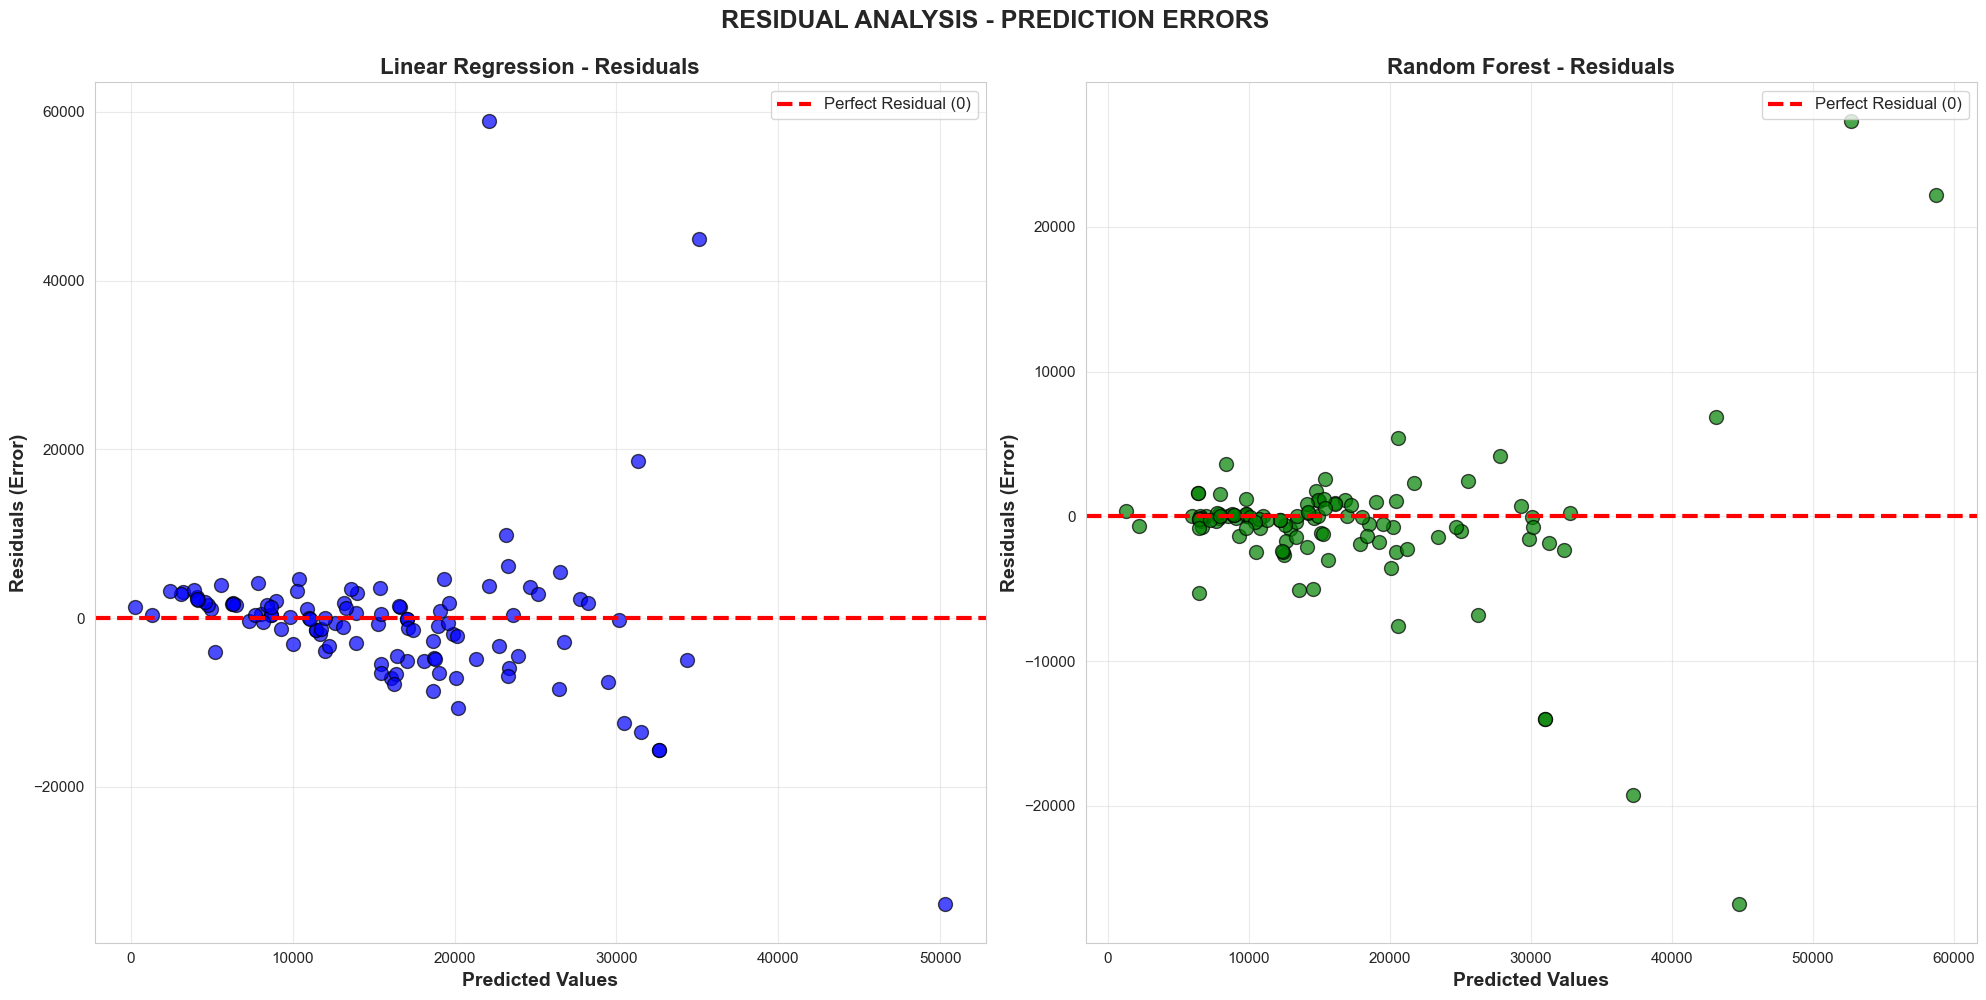

In [15]:
# Residual Analysis
print("\n" + "="*50)
print("Residual Analysis")
print("="*50)

residuals_lr = y_test - y_test_pred_lr
residuals_rf = y_test - y_test_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Linear Regression Residuals
axes[0].scatter(y_test_pred_lr, residuals_lr, alpha=0.7, color='blue', s=100, edgecolor='black', linewidth=1)
axes[0].axhline(y=0, color='r', linestyle='--', lw=3, label='Perfect Residual (0)')
axes[0].set_xlabel('Predicted Values', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Residuals (Error)', fontsize=14, fontweight='bold')
axes[0].set_title('Linear Regression - Residuals', fontsize=16, fontweight='bold')
axes[0].grid(True, alpha=0.4)
axes[0].legend(fontsize=12)
axes[0].tick_params(labelsize=11)

# Random Forest Residuals
axes[1].scatter(y_test_pred_rf, residuals_rf, alpha=0.7, color='green', s=100, edgecolor='black', linewidth=1)
axes[1].axhline(y=0, color='r', linestyle='--', lw=3, label='Perfect Residual (0)')
axes[1].set_xlabel('Predicted Values', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Residuals (Error)', fontsize=14, fontweight='bold')
axes[1].set_title('Random Forest - Residuals', fontsize=16, fontweight='bold')
axes[1].grid(True, alpha=0.4)
axes[1].legend(fontsize=12)
axes[1].tick_params(labelsize=11)
fig.suptitle('RESIDUAL ANALYSIS - PREDICTION ERRORS', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [16]:
# Final Summary
print("\n" + "="*70)
print("ANALYSIS SUMMARY")
print("="*70)

print(f"\n Dataset Information:")
print(f"   • Total Samples: {len(df)}")
print(f"   • Total Features: {X.shape[1]}")
print(f"   • Target Variable: {target_col}")

print(f"\n Data Split:")
print(f"   • Training Samples: {X_train.shape[0]}")
print(f"   • Test Samples: {X_test.shape[0]}")

print(f"\n Model Performance (Test Set):")
print(f"\n   Linear Regression:")
print(f"     - MAE:  {test_mae_lr:.4f}")
print(f"     - RMSE: {test_rmse_lr:.4f}")
print(f"     - R²:   {test_r2_lr:.4f}")

print(f"\n   Random Forest:")
print(f"     - MAE:  {test_mae_rf:.4f}")
print(f"     - RMSE: {test_rmse_rf:.4f}")
print(f"     - R²:   {test_r2_rf:.4f}")

print(f"\n Best Performing Model: {best_model}")
print("\n" + "="*70)


ANALYSIS SUMMARY

 Dataset Information:
   • Total Samples: 541
   • Total Features: 6
   • Target Variable: Prize

 Data Split:
   • Training Samples: 432
   • Test Samples: 109

 Model Performance (Test Set):

   Linear Regression:
     - MAE:  4667.4875
     - RMSE: 9209.6260
     - R²:   0.3846

   Random Forest:
     - MAE:  2365.5303
     - RMSE: 5378.1873
     - R²:   0.7901

 Best Performing Model: Random Forest

